In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as units
import astropy.constants as const
from scipy.special import wofz
from tqdm import tqdm
from rtfunctions import one_full_fs, sc_2nd_order, calc_lambda_full, calc_lambda_monoc
import time
import illuminated_finite_slab as ill

<h2>Playground for 2 components</h2>
<p>Testing out the illuminated finite slab module. So far it works for a single component, but we are now trying to extend it to two components. We want to produce the He I 1083 nm line profile.</p>

In [2]:
# Let's create a slab first
ND = 51
tau_max = 1e3
epsilon = np.ones(ND) * 5e-3
B = np.ones(ND) * 5.0

slab = ill.Slab(ND, tau_max, epsilon, B, H=70000.0)

In [3]:
# Calculate the scattered J
slab.calculate_J_scat()

Converged after 57 iterations.


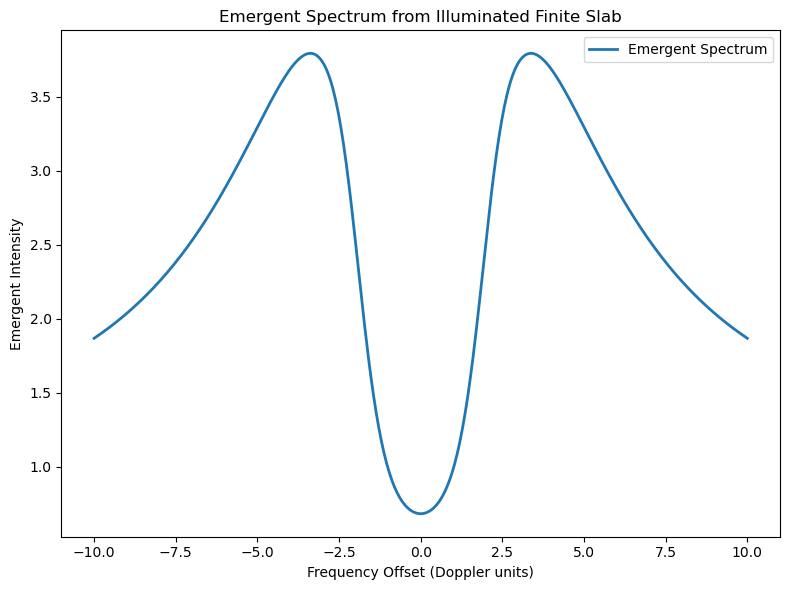

In [4]:
# First, solve for one component
slab.solve_source_function_ALO(max_iter=500, tol=1e-6)
S_alo = slab.S

# Second, create an observed spectrum
x_obs = np.linspace(-10, 10, 501)  # Frequency grid
slab.a = 0.1 # Set damping parameter
spectrum = slab.formal_solution_given_direction(mu_obs=1.0, x_obs=x_obs, boundary_condition=1.0, recalc_profile=True)

slab.solve_source_function()
S_direct = slab.S

# Plot the results
plt.figure(figsize=(8,6))
plt.plot(x_obs, spectrum, linewidth = 2, label="Emergent Spectrum")
plt.xlabel("Frequency Offset (Doppler units)")
plt.ylabel("Emergent Intensity")
plt.title("Emergent Spectrum from Illuminated Finite Slab")
plt.legend()
plt.tight_layout()

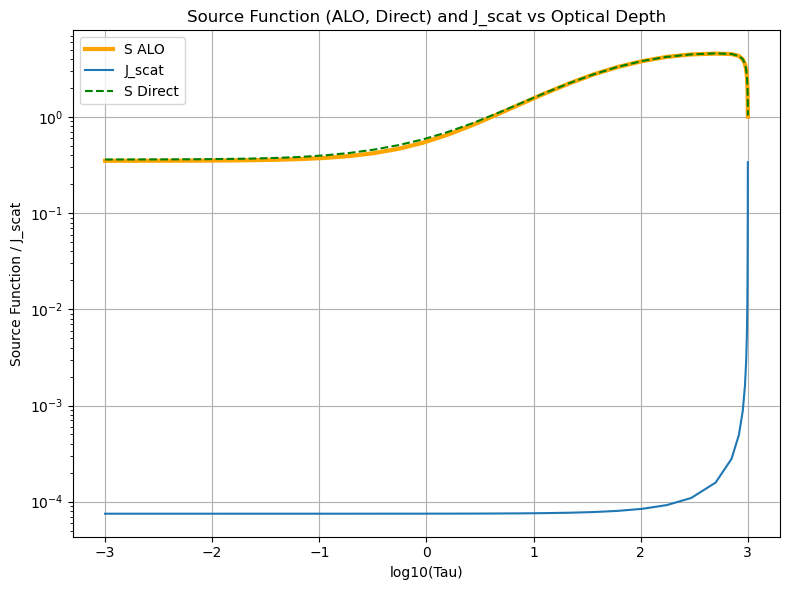

In [5]:
plt.figure(figsize=(8,6))
plt.semilogy(np.log10(slab.tau),S_alo, linestyle = "-", linewidth = 3, color = "orange", label="S ALO")
plt.semilogy(np.log10(slab.tau),slab.J_scat, label="J_scat")
plt.semilogy(np.log10(slab.tau),S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
#plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("log10(Tau)")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function (ALO, Direct) and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

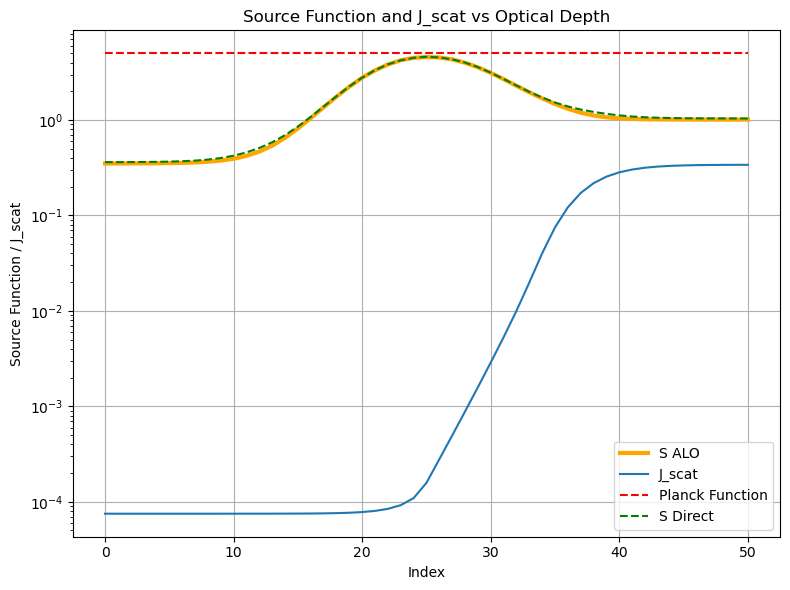

In [6]:
# Other variant where we use the depth index to plot all the variables
plt.figure(figsize=(8,6))
plt.semilogy(S_alo, linestyle = "-", linewidth = 3, color = "orange", label="S ALO")
plt.semilogy(slab.J_scat, label="J_scat")
plt.semilogy(slab.B, linestyle = "--", color = "red", alpha = 1.0, label="Planck Function")
plt.semilogy(S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
#plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("Index")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

<h3>So far, so good...</h3>
<p>This is within the expectacions and in accordance with literature.</p>
<h3>But what about two components?</h3>
<p>The next step is to define two-component profiles in the same slab. The idea is to have two different sets of parameters for the two components, and then combine their contributions to get the final profile.</p>
<p>We will need to define parameters such as optical depth, Doppler width, and source function for each component separately. Then, we can compute the emergent intensity by summing the contributions from both components.</p>
<p>Let's implement this and see how the resulting profile looks compared to the single-component case.</p>

In [7]:
slab2 = ill.Slab(ND, tau_max, epsilon, B, H=10e6) # Note height in m

<p>After some consideration, we have decided to use Lambda iteration instead of ALI for the initial attempt to model two components. This approach will me slightly slower, but it will be easier to write. </p>
<p> Absorption WIP </p>

In [8]:
# Second, create an observed spectrum
x_obs = np.linspace(-10, 10, 501)  # Frequency grid
slab.a = 0.1 # Set damping parameter
spectrum = slab2.formal_solution_given_direction(mu_obs=1.0, x_obs=x_obs, boundary_condition=1.0, recalc_profile=True)

slab2.calculate_J_scat()

slab2.solve_source_function_LI_2comp()
S_LI = slab2.S

In [9]:
print(np.shape(slab2.J_scat))
print(np.shape(slab2.phi))

(51,)
(41,)


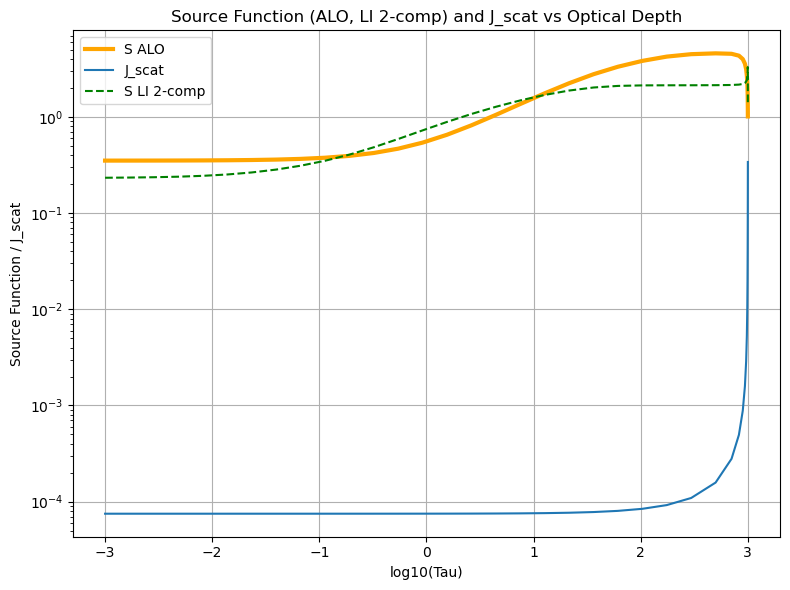

In [10]:
plt.figure(figsize=(8,6))
plt.semilogy(np.log10(slab.tau),S_alo, linestyle = "-", linewidth = 3, color = "orange", label="S ALO")
plt.semilogy(np.log10(slab.tau),slab.J_scat, label="J_scat")
plt.semilogy(np.log10(slab.tau),S_LI, linestyle = "--", color = "green", alpha = 1.0, label="S LI 2-comp")
#plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("log10(Tau)")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function (ALO, LI 2-comp) and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

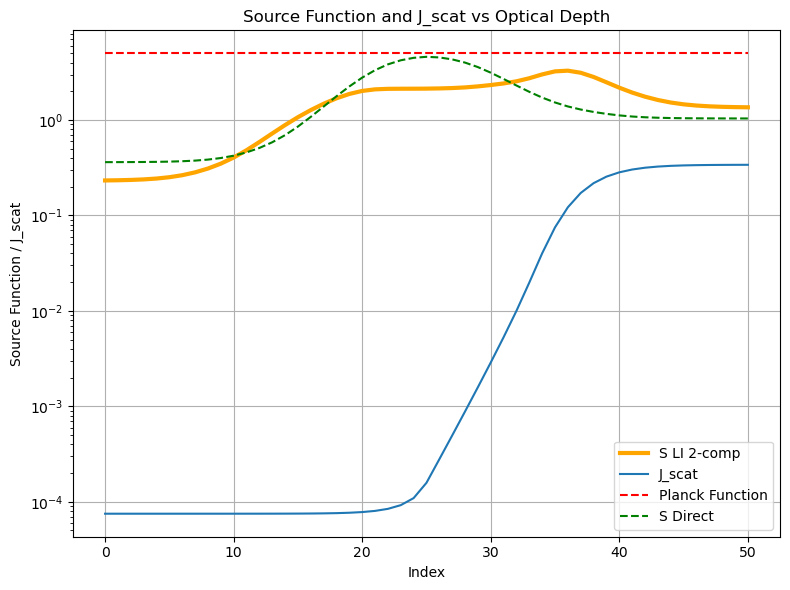

In [11]:
 # Other variant where we use the depth index to plot all the variables
plt.figure(figsize=(8,6))
plt.semilogy(S_LI, linestyle = "-", linewidth = 3, color = "orange", label="S LI 2-comp")
plt.semilogy(slab.J_scat, label="J_scat")
plt.semilogy(slab.B, linestyle = "--", color = "red", alpha = 1.0, label="Planck Function")
plt.semilogy(S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
# plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("Index")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

<h2>28. 01. 2026.</h2>
<p> The approach showed above needs refinement. </p>

In [12]:
slab3 = ill.Slab(ND, tau_max, epsilon, B, H=10e6) # Note height in m

# Second, create an observed spectrum
x_obs = np.linspace(-10, 10, 501)  # Frequency grid
slab3.a = 0.1 # Set damping parameter
spectrum = slab3.formal_solution_given_direction(mu_obs=1.0, x_obs=x_obs, boundary_condition=1.0, recalc_profile=True)

slab3.calculate_J_scat()

slab3.composite_source()
S_composite = slab3.S

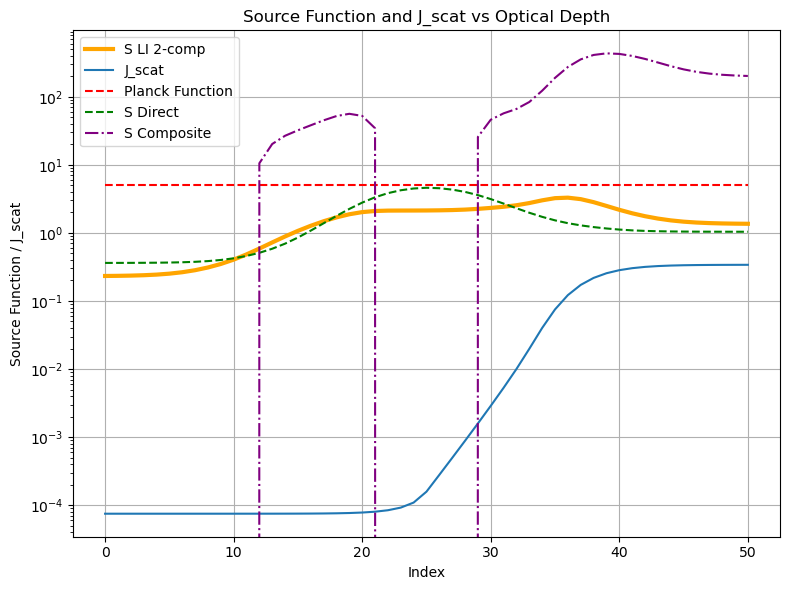

In [13]:
plt.figure(figsize=(8,6))
plt.semilogy(S_LI, linestyle = "-", linewidth = 3, color = "orange", label="S LI 2-comp")
plt.semilogy(slab.J_scat, label="J_scat")
plt.semilogy(slab.B, linestyle = "--", color = "red", alpha = 1.0, label="Planck Function")
plt.semilogy(S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
plt.semilogy(S_composite, linestyle = "-.", color = "purple", alpha = 1.0, label="S Composite")
# plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("Index")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

[-123.28239429 -122.11154096 -120.17490317 -117.01593893 -111.98337515
 -104.26530432  -93.10768012  -78.29512787  -60.60511651  -41.44677716
  -21.98755842   -3.83730455   10.53390355   20.21828589   26.7079651
   32.15049664   38.07782172   45.01123802   52.02921505   56.16135521
   52.27045765   34.49287932   -0.58271495  -49.24109782  -95.41259817
 -113.90672329  -93.96951719  -51.76141992   -7.69317766   25.66359818
   45.96023947   57.04711393   66.15778866   83.69962954  122.65601109
  189.37391919  273.55322064  353.9708589   410.91625204  433.83916821
  425.64342273  397.62732796  359.38247532  318.32393399  281.33676347
  252.44508252  232.07917609  218.66313689  210.19351622  204.98412002
  201.82854234]


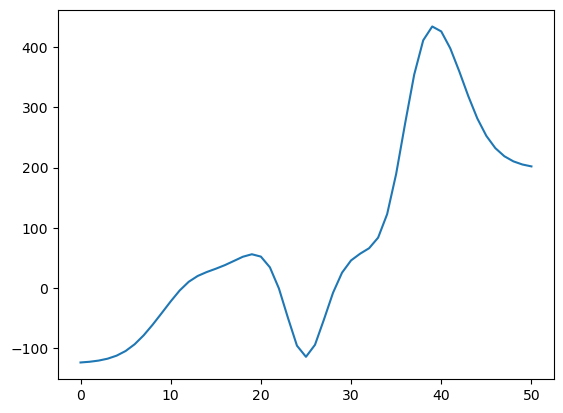

In [15]:
print(S_composite)
plt.plot(S_composite)